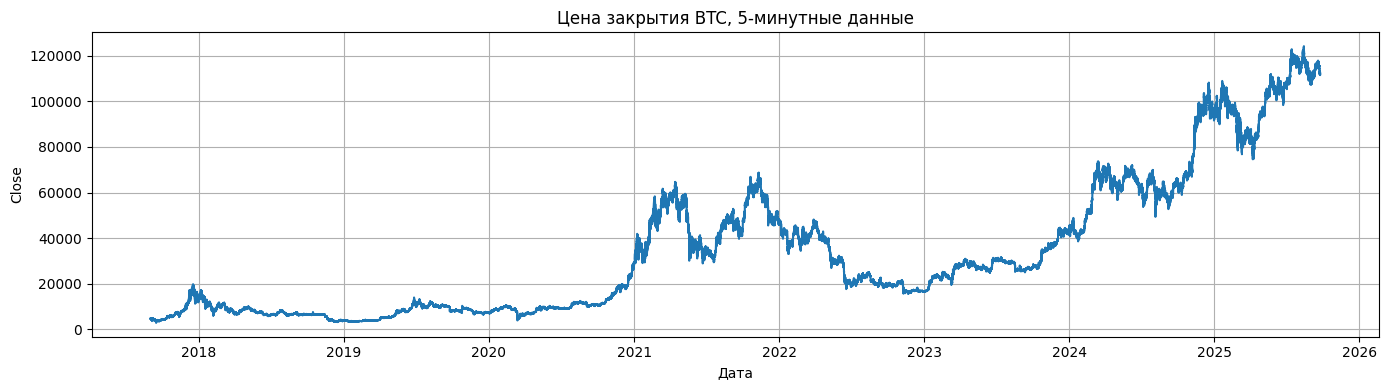

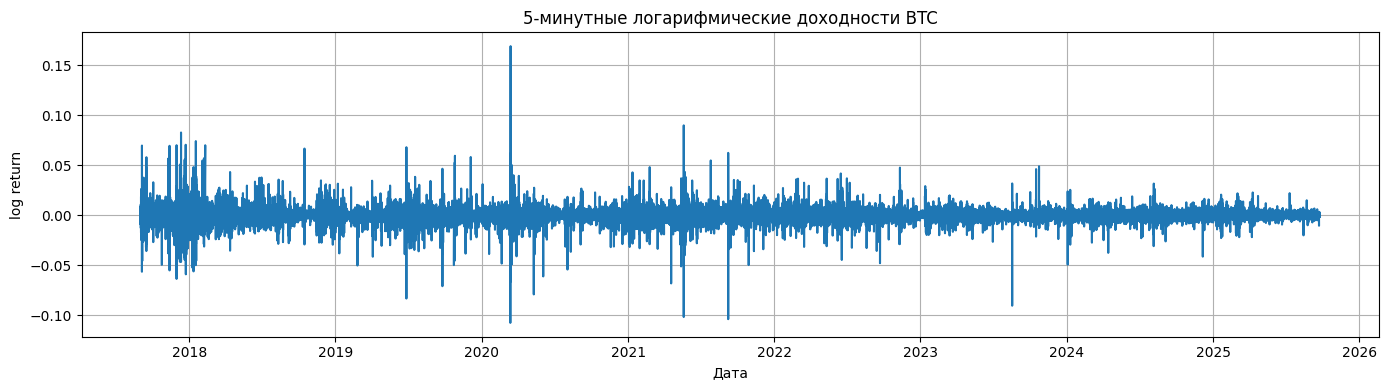

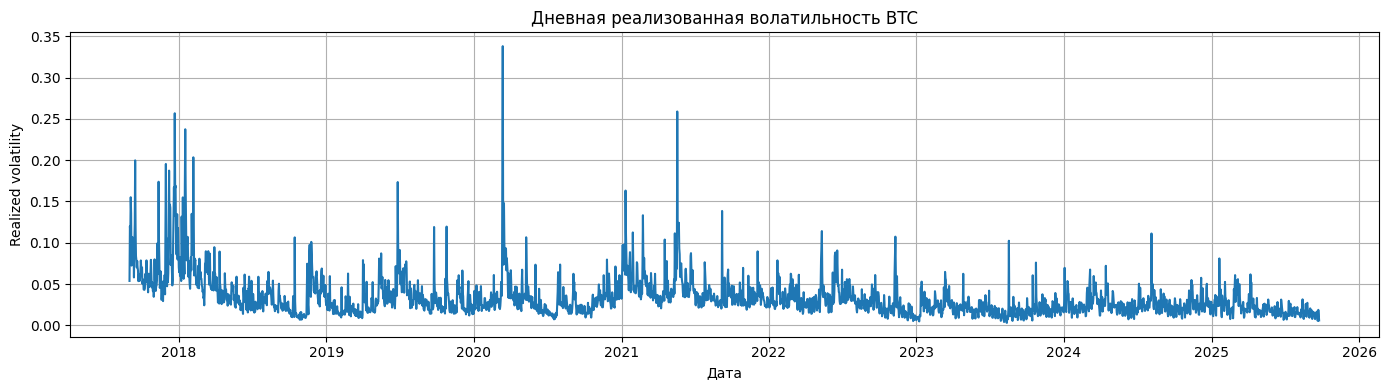

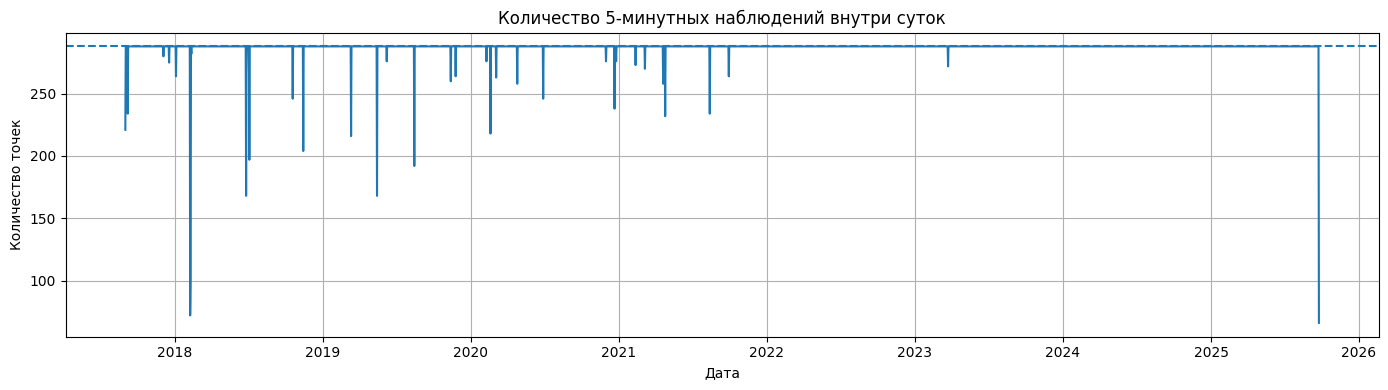

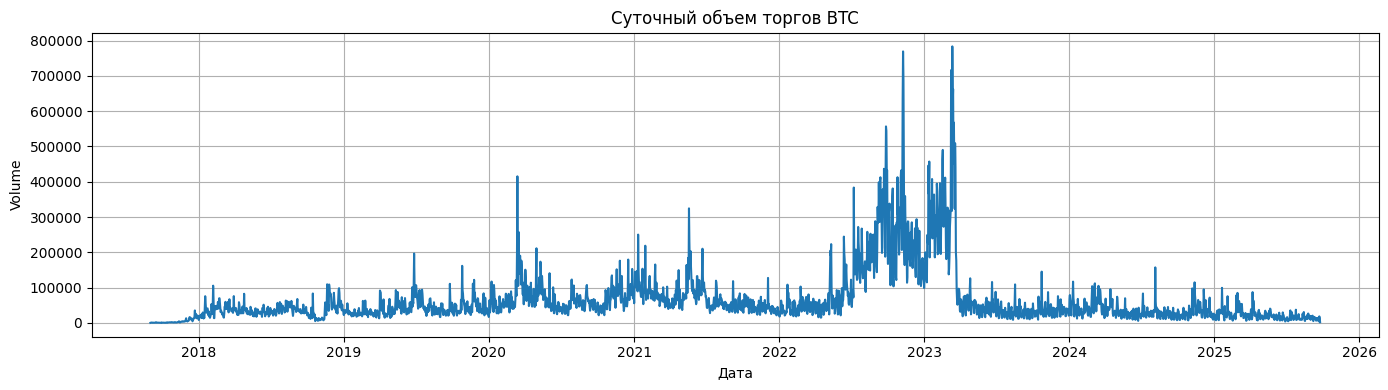

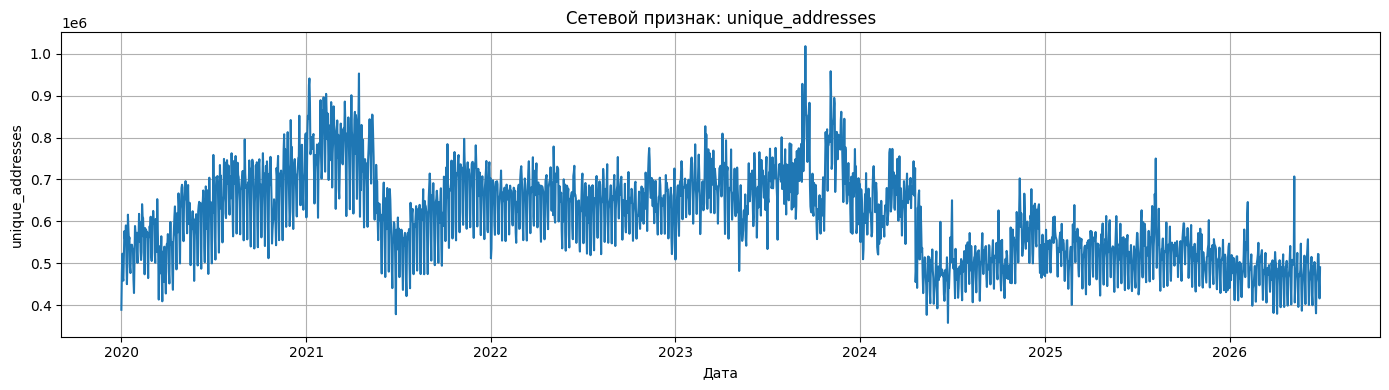

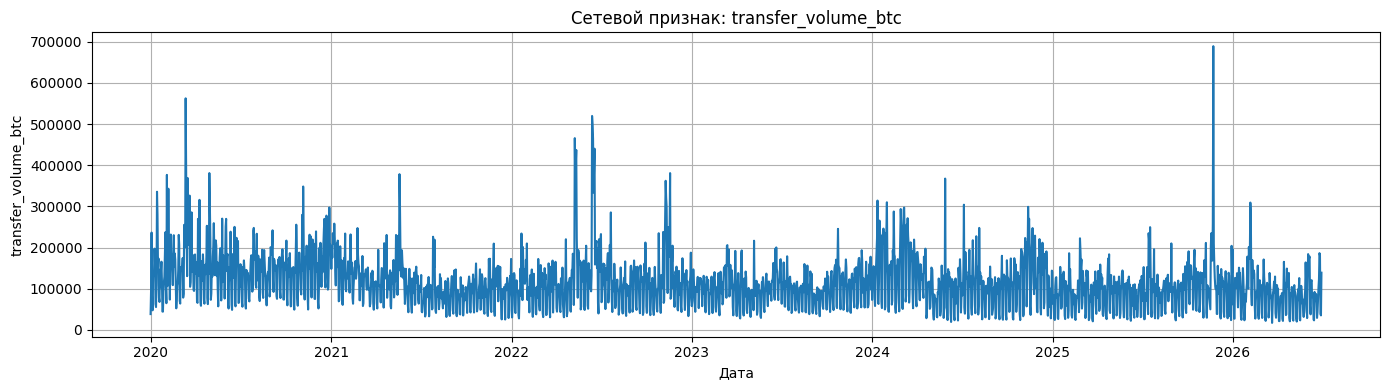

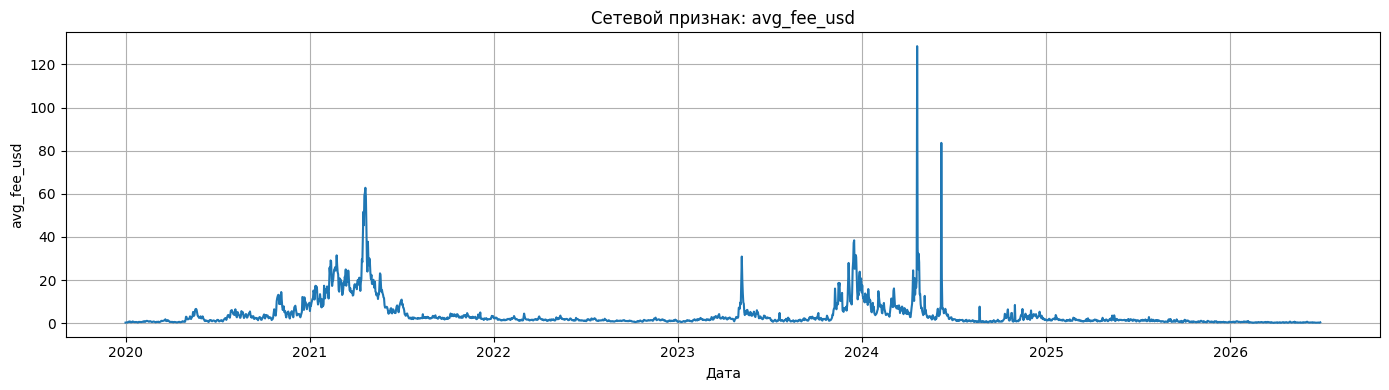

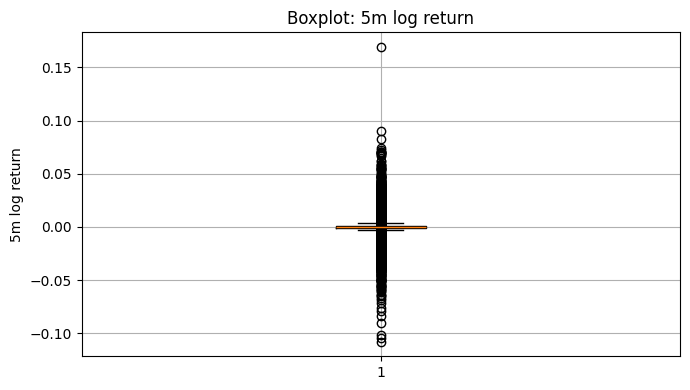

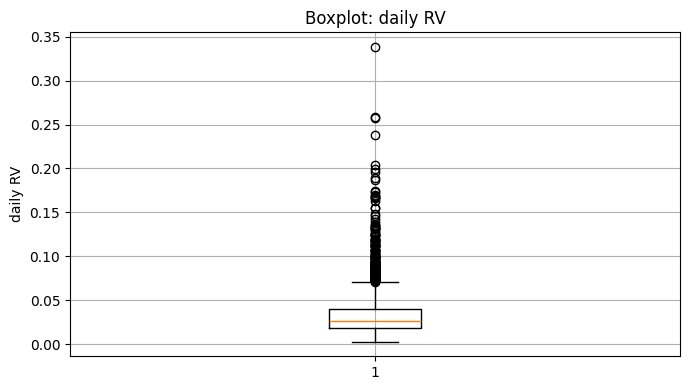

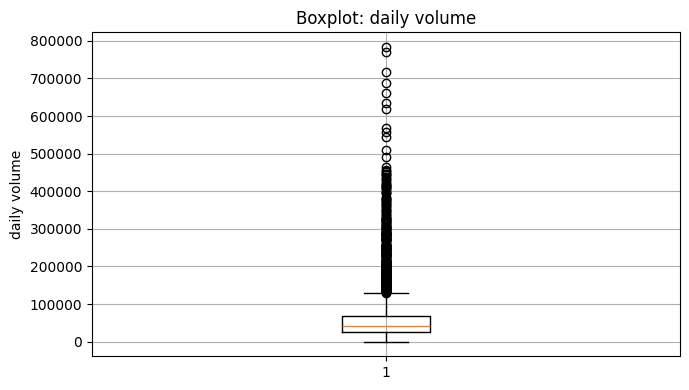

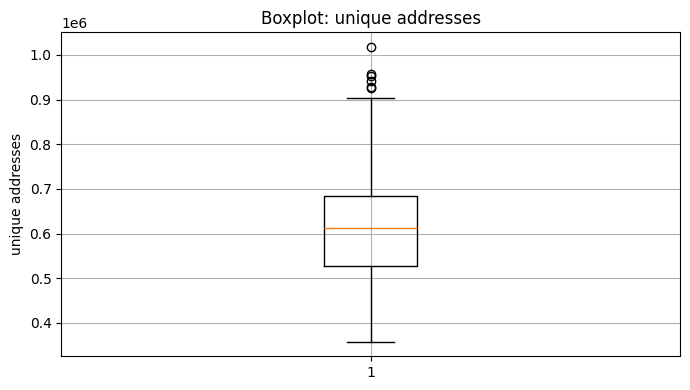

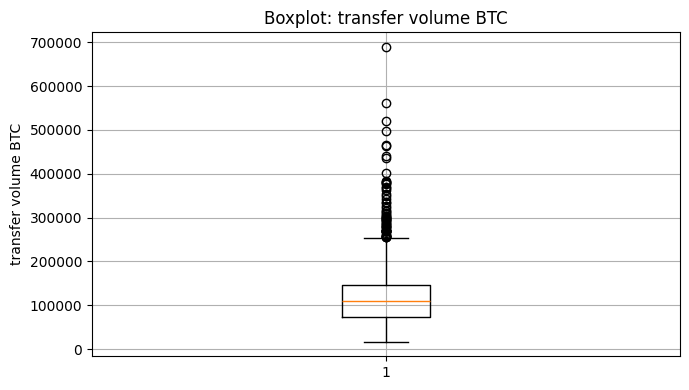

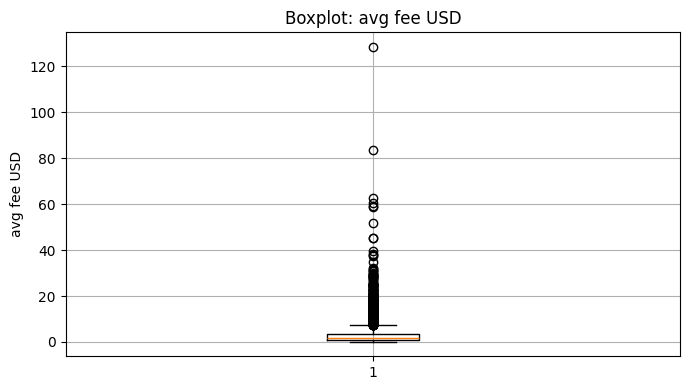

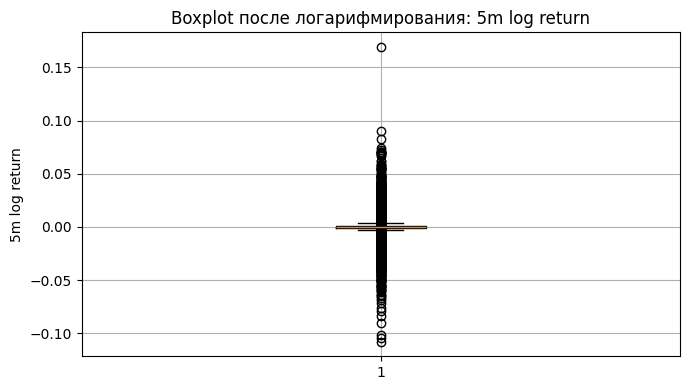

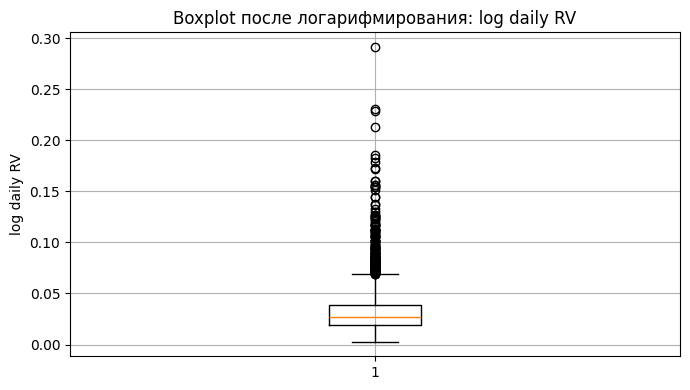

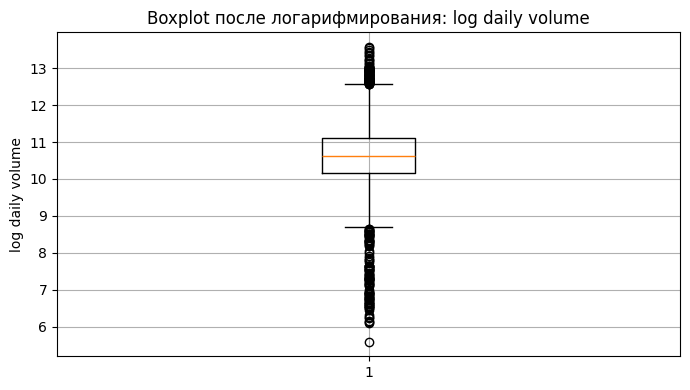

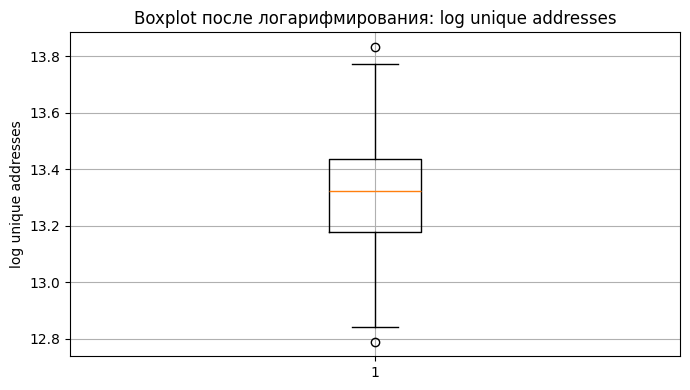

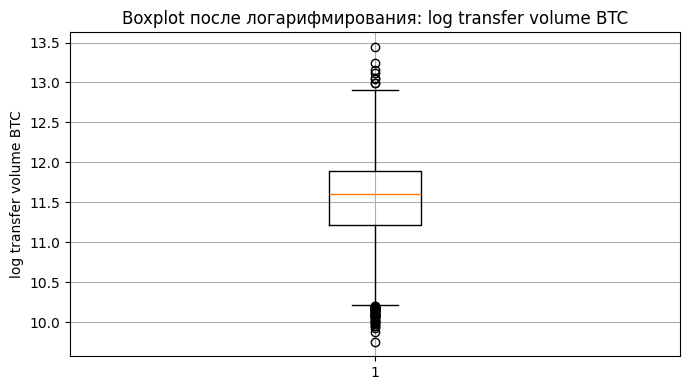

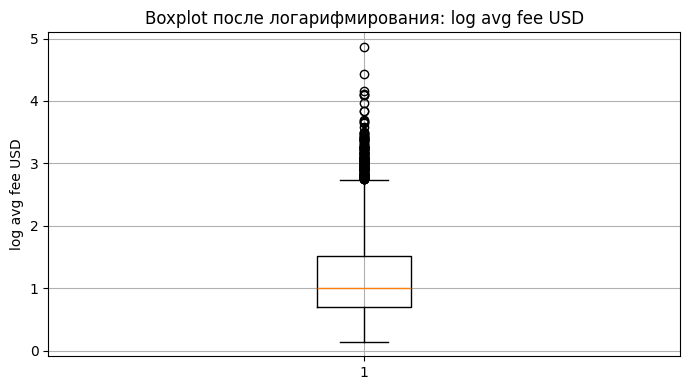

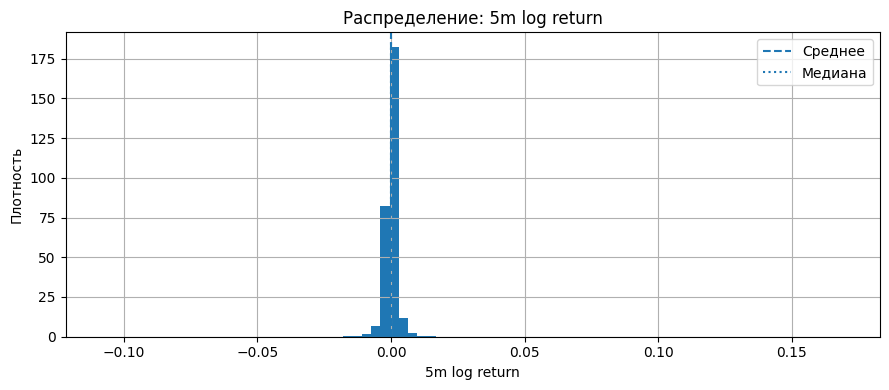

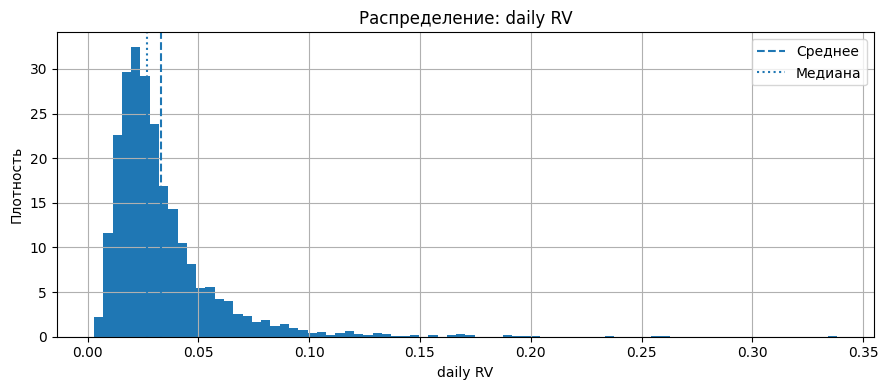

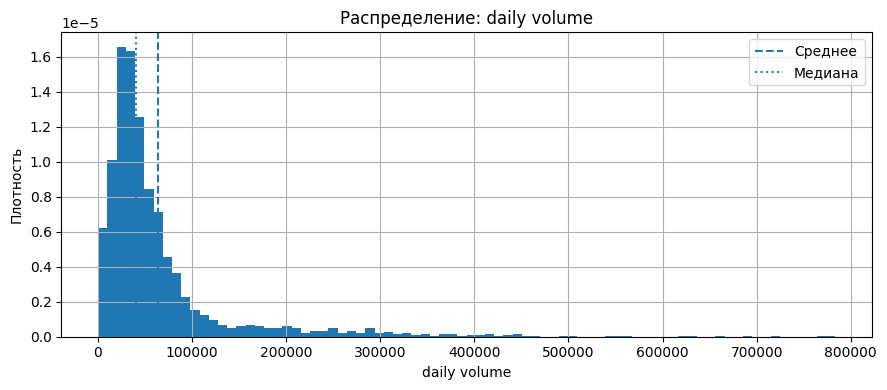

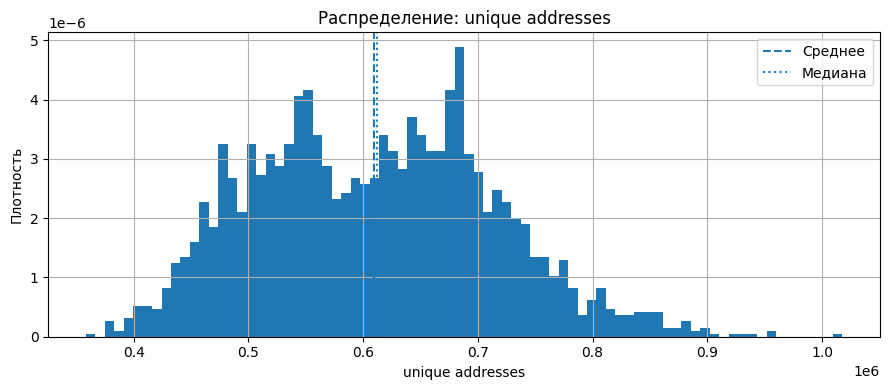

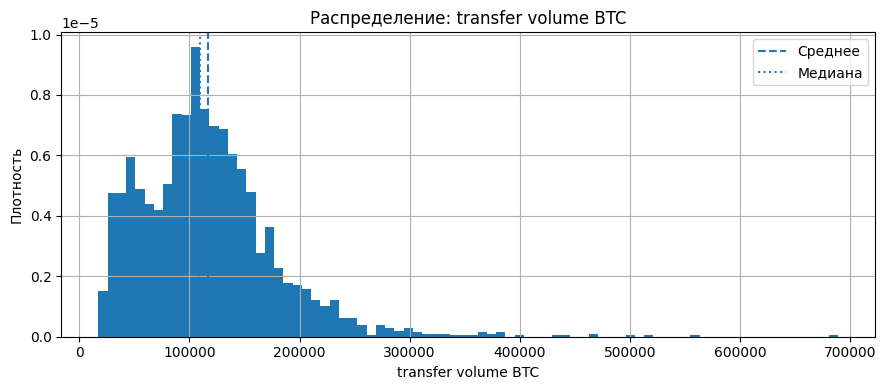

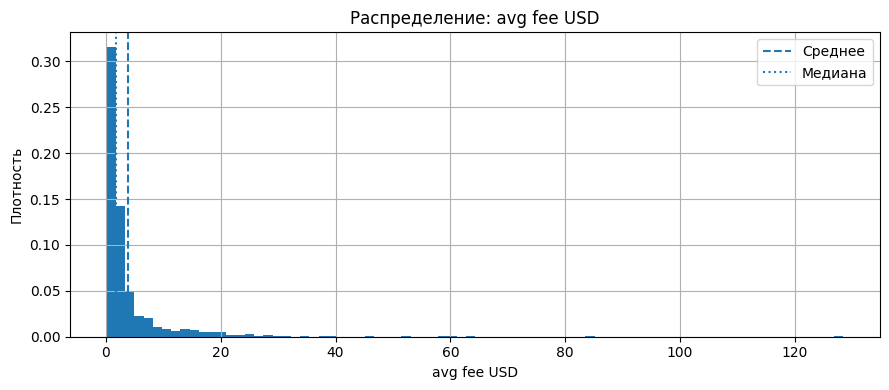

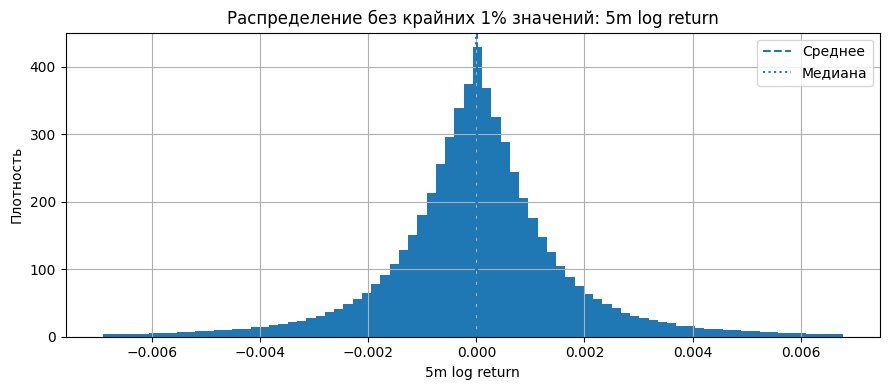

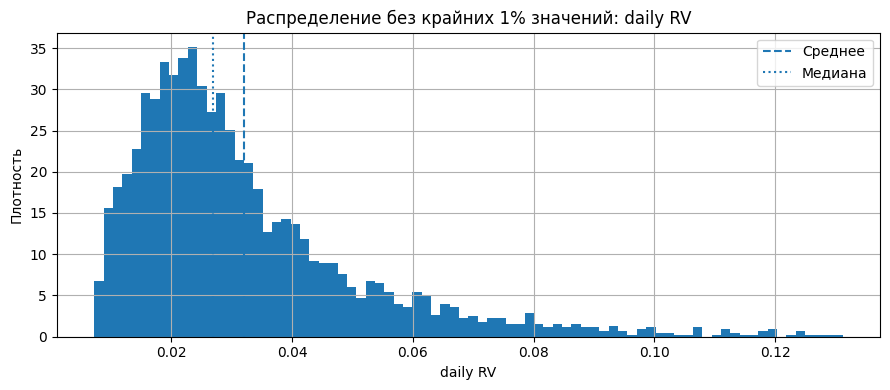

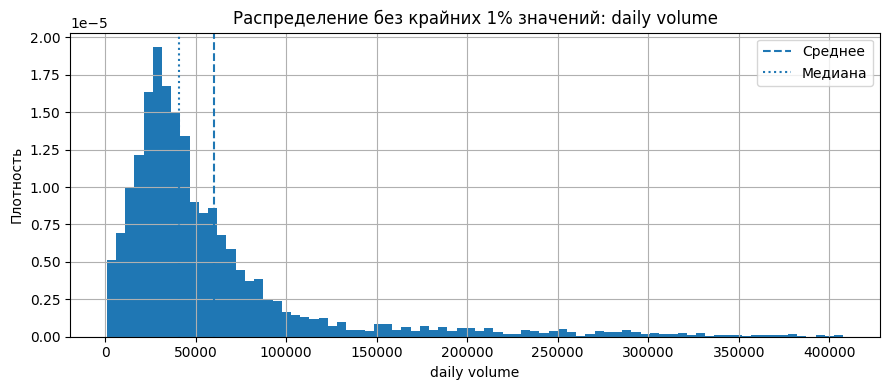

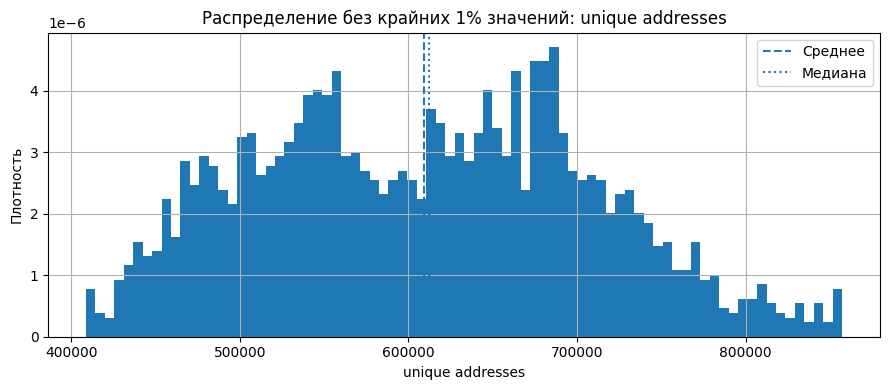

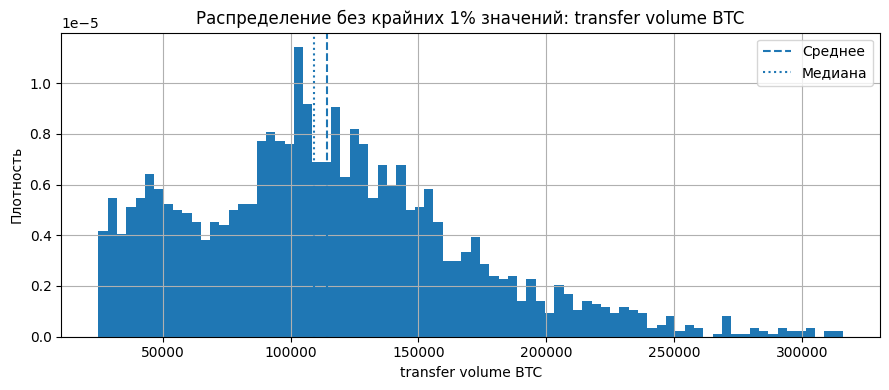

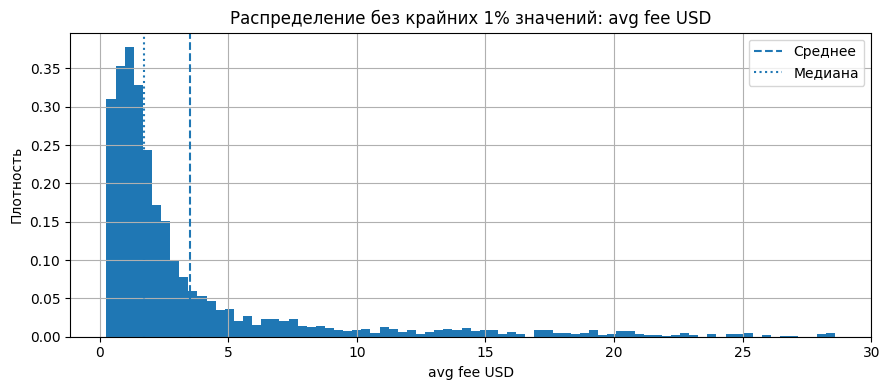

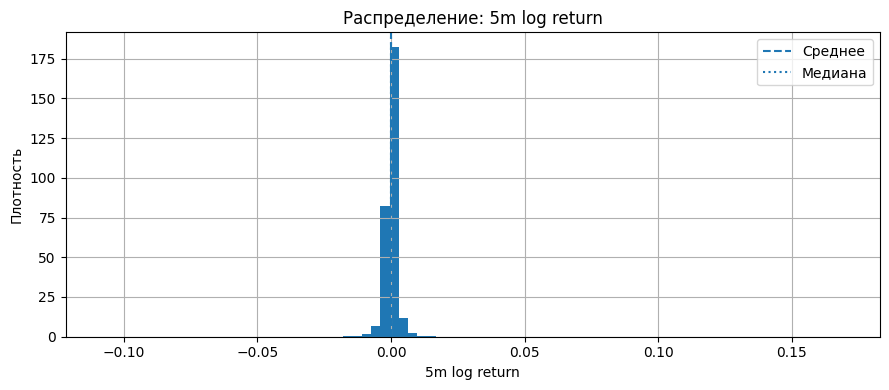

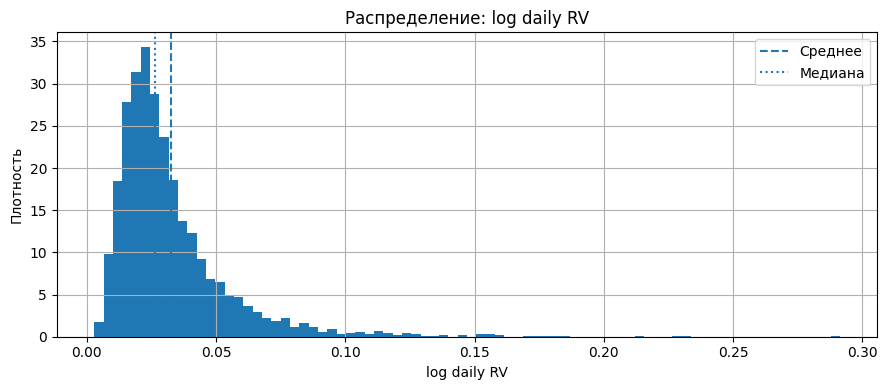

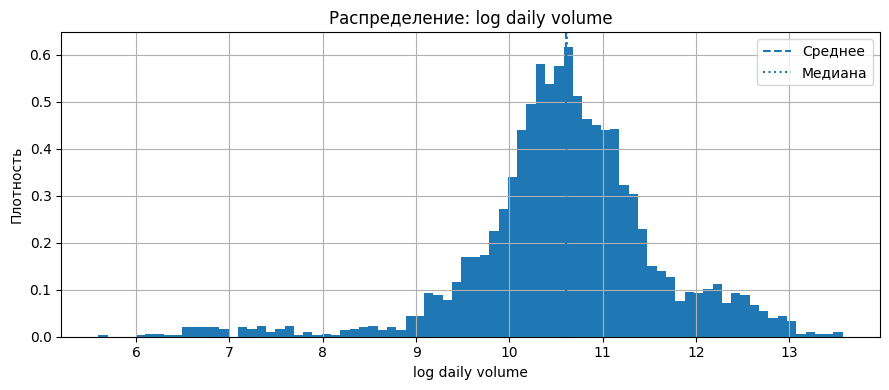

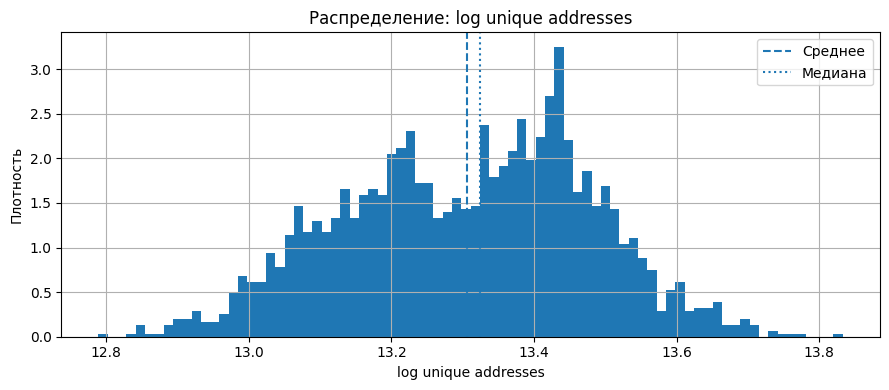

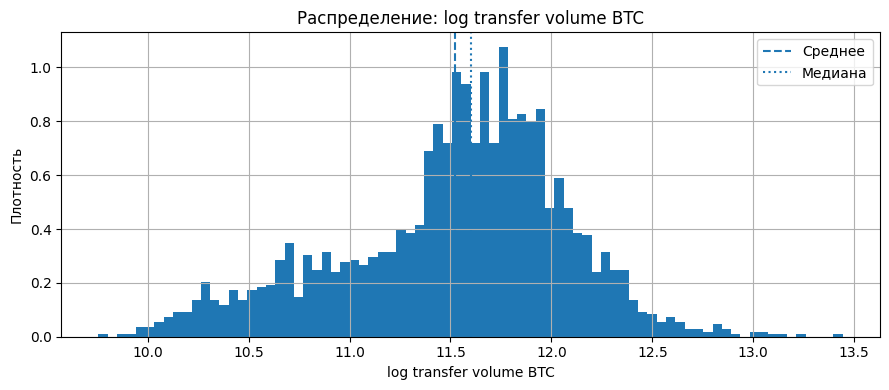

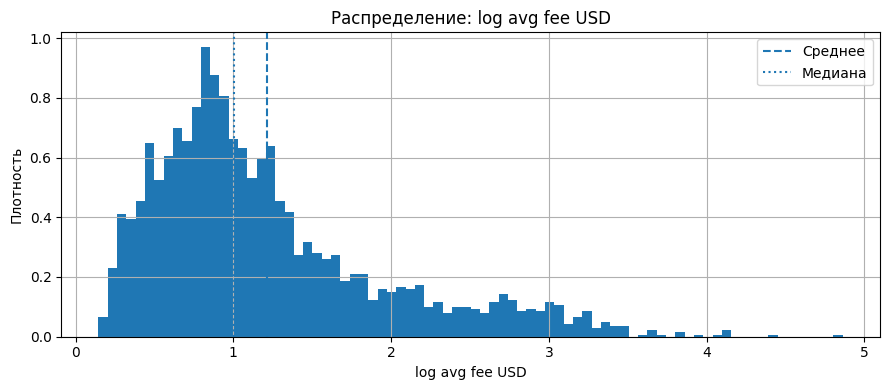

Графики сохранены в папку: C:\Users\gasos\OneDrive\Рабочий стол\Магистратура\мага 4 модуль\Учебная практика\python\results\visual_data_check


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


MARKET_CSV = Path("../data/raw/btc_5m_ohlcv.csv")
NETWORK_CSV = Path("../data/raw/btc_network_daily.csv")

OUTPUT_DIR = Path("../results/visual_data_check")
TIME_SERIES_DIR = OUTPUT_DIR / "time_series"
BOXPLOTS_DIR = OUTPUT_DIR / "boxplots"
DISTRIBUTIONS_DIR = OUTPUT_DIR / "distributions"

for directory in [TIME_SERIES_DIR, BOXPLOTS_DIR, DISTRIBUTIONS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def save_and_show(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_distribution(values, title, xlabel, filename, bins=80):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()

    if values.empty:
        print(f"Нет данных для построения распределения: {title}")
        return

    plt.figure(figsize=(9, 4))
    plt.hist(values, bins=bins, density=True)
    plt.axvline(values.mean(), linestyle="--", label="Среднее")
    plt.axvline(values.median(), linestyle=":", label="Медиана")
    plt.title(f"Распределение: {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Плотность")
    plt.legend()
    plt.grid(True)

    save_and_show(DISTRIBUTIONS_DIR / filename)


def plot_distribution_trimmed(
    values,
    title,
    xlabel,
    filename,
    lower_q=0.01,
    upper_q=0.99,
    bins=80,
):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()

    if values.empty:
        print(f"Нет данных для построения распределения: {title}")
        return

    lower = values.quantile(lower_q)
    upper = values.quantile(upper_q)
    trimmed = values[(values >= lower) & (values <= upper)]

    plt.figure(figsize=(9, 4))
    plt.hist(trimmed, bins=bins, density=True)
    plt.axvline(trimmed.mean(), linestyle="--", label="Среднее")
    plt.axvline(trimmed.median(), linestyle=":", label="Медиана")
    plt.title(f"Распределение без крайних 1% значений: {title}")
    plt.xlabel(xlabel)
    plt.ylabel("Плотность")
    plt.legend()
    plt.grid(True)

    save_and_show(DISTRIBUTIONS_DIR / filename)


market = pd.read_csv(MARKET_CSV)

market["timestamp"] = pd.to_datetime(market["timestamp"], utc=True)

for col in ["open", "high", "low", "close", "volume"]:
    market[col] = pd.to_numeric(market[col], errors="coerce")

market = (
    market
    .dropna(subset=["timestamp", "close"])
    .drop_duplicates(subset=["timestamp"], keep="last")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

market["log_return"] = np.log(market["close"] / market["close"].shift(1))
market["log_return"] = market["log_return"].replace([np.inf, -np.inf], np.nan)
market["date_utc"] = market["timestamp"].dt.floor("D")


daily_market = (
    market
    .dropna(subset=["log_return"])
    .groupby("date_utc")
    .agg(
        realized_volatility=("log_return", lambda x: np.sqrt(np.sum(x ** 2))),
        intraday_points=("close", "size"),
        daily_volume=("volume", "sum"),
    )
    .reset_index()
)


network = pd.read_csv(NETWORK_CSV)

network["date_utc"] = pd.to_datetime(network["date"], utc=True).dt.floor("D")

for col in ["unique_addresses", "transfer_volume_btc", "avg_fee_usd"]:
    network[col] = pd.to_numeric(network[col], errors="coerce")

network = (
    network
    .dropna(subset=["date_utc"])
    .sort_values("date_utc")
    .reset_index(drop=True)
)


plt.figure(figsize=(14, 4))
plt.plot(market["timestamp"], market["close"])
plt.title("Цена закрытия BTC, 5-минутные данные")
plt.xlabel("Дата")
plt.ylabel("Close")
plt.grid(True)
save_and_show(TIME_SERIES_DIR / "01_btc_5m_close_price.png")


plt.figure(figsize=(14, 4))
plt.plot(market["timestamp"], market["log_return"])
plt.title("5-минутные логарифмические доходности BTC")
plt.xlabel("Дата")
plt.ylabel("log return")
plt.grid(True)
save_and_show(TIME_SERIES_DIR / "02_btc_5m_log_returns.png")


plt.figure(figsize=(14, 4))
plt.plot(daily_market["date_utc"], daily_market["realized_volatility"])
plt.title("Дневная реализованная волатильность BTC")
plt.xlabel("Дата")
plt.ylabel("Realized volatility")
plt.grid(True)
save_and_show(TIME_SERIES_DIR / "03_btc_daily_realized_volatility.png")


plt.figure(figsize=(14, 4))
plt.plot(daily_market["date_utc"], daily_market["intraday_points"])
plt.axhline(288, linestyle="--")
plt.title("Количество 5-минутных наблюдений внутри суток")
plt.xlabel("Дата")
plt.ylabel("Количество точек")
plt.grid(True)
save_and_show(TIME_SERIES_DIR / "04_intraday_points_per_day.png")


plt.figure(figsize=(14, 4))
plt.plot(daily_market["date_utc"], daily_market["daily_volume"])
plt.title("Суточный объем торгов BTC")
plt.xlabel("Дата")
plt.ylabel("Volume")
plt.grid(True)
save_and_show(TIME_SERIES_DIR / "05_btc_daily_volume.png")


network_plot_files = {
    "unique_addresses": "06_network_unique_addresses.png",
    "transfer_volume_btc": "07_network_transfer_volume_btc.png",
    "avg_fee_usd": "08_network_avg_fee_usd.png",
}

for col, filename in network_plot_files.items():
    plt.figure(figsize=(14, 4))
    plt.plot(network["date_utc"], network[col])
    plt.title(f"Сетевой признак: {col}")
    plt.xlabel("Дата")
    plt.ylabel(col)
    plt.grid(True)
    save_and_show(TIME_SERIES_DIR / filename)


boxplot_data = {
    "5m log return": {
        "values": market["log_return"].dropna(),
        "filename": "01_boxplot_5m_log_return.png",
    },
    "daily RV": {
        "values": daily_market["realized_volatility"].dropna(),
        "filename": "02_boxplot_daily_realized_volatility.png",
    },
    "daily volume": {
        "values": daily_market["daily_volume"].dropna(),
        "filename": "03_boxplot_daily_volume.png",
    },
    "unique addresses": {
        "values": network["unique_addresses"].dropna(),
        "filename": "04_boxplot_unique_addresses.png",
    },
    "transfer volume BTC": {
        "values": network["transfer_volume_btc"].dropna(),
        "filename": "05_boxplot_transfer_volume_btc.png",
    },
    "avg fee USD": {
        "values": network["avg_fee_usd"].dropna(),
        "filename": "06_boxplot_avg_fee_usd.png",
    },
}


for title, item in boxplot_data.items():
    values = item["values"]

    plt.figure(figsize=(7, 4))
    plt.boxplot(values, showfliers=True)
    plt.title(f"Boxplot: {title}")
    plt.ylabel(title)
    plt.grid(True)

    save_and_show(BOXPLOTS_DIR / item["filename"])


log_boxplot_data = {
    "5m log return": {
        "values": market["log_return"].dropna(),
        "filename": "07_boxplot_log_5m_log_return.png",
    },
    "log daily RV": {
        "values": np.log1p(daily_market["realized_volatility"].dropna()),
        "filename": "08_boxplot_log1p_daily_realized_volatility.png",
    },
    "log daily volume": {
        "values": np.log1p(daily_market["daily_volume"].dropna()),
        "filename": "09_boxplot_log1p_daily_volume.png",
    },
    "log unique addresses": {
        "values": np.log1p(network["unique_addresses"].dropna()),
        "filename": "10_boxplot_log1p_unique_addresses.png",
    },
    "log transfer volume BTC": {
        "values": np.log1p(network["transfer_volume_btc"].dropna()),
        "filename": "11_boxplot_log1p_transfer_volume_btc.png",
    },
    "log avg fee USD": {
        "values": np.log1p(network["avg_fee_usd"].dropna()),
        "filename": "12_boxplot_log1p_avg_fee_usd.png",
    },
}


for title, item in log_boxplot_data.items():
    values = item["values"]

    plt.figure(figsize=(7, 4))
    plt.boxplot(values, showfliers=True)
    plt.title(f"Boxplot после логарифмирования: {title}")
    plt.ylabel(title)
    plt.grid(True)

    save_and_show(BOXPLOTS_DIR / item["filename"])


distribution_data = {
    "5m log return": {
        "values": market["log_return"].dropna(),
        "filename": "01_distribution_5m_log_return.png",
        "trimmed_filename": "07_distribution_trimmed_5m_log_return.png",
    },
    "daily RV": {
        "values": daily_market["realized_volatility"].dropna(),
        "filename": "02_distribution_daily_realized_volatility.png",
        "trimmed_filename": "08_distribution_trimmed_daily_realized_volatility.png",
    },
    "daily volume": {
        "values": daily_market["daily_volume"].dropna(),
        "filename": "03_distribution_daily_volume.png",
        "trimmed_filename": "09_distribution_trimmed_daily_volume.png",
    },
    "unique addresses": {
        "values": network["unique_addresses"].dropna(),
        "filename": "04_distribution_unique_addresses.png",
        "trimmed_filename": "10_distribution_trimmed_unique_addresses.png",
    },
    "transfer volume BTC": {
        "values": network["transfer_volume_btc"].dropna(),
        "filename": "05_distribution_transfer_volume_btc.png",
        "trimmed_filename": "11_distribution_trimmed_transfer_volume_btc.png",
    },
    "avg fee USD": {
        "values": network["avg_fee_usd"].dropna(),
        "filename": "06_distribution_avg_fee_usd.png",
        "trimmed_filename": "12_distribution_trimmed_avg_fee_usd.png",
    },
}


for title, item in distribution_data.items():
    plot_distribution(
        values=item["values"],
        title=title,
        xlabel=title,
        filename=item["filename"],
        bins=80,
    )


for title, item in distribution_data.items():
    plot_distribution_trimmed(
        values=item["values"],
        title=title,
        xlabel=title,
        filename=item["trimmed_filename"],
        bins=80,
    )


log_distribution_data = {
    "5m log return": {
        "values": market["log_return"].dropna(),
        "filename": "13_distribution_log_5m_log_return.png",
    },
    "log daily RV": {
        "values": np.log1p(daily_market["realized_volatility"].dropna()),
        "filename": "14_distribution_log1p_daily_realized_volatility.png",
    },
    "log daily volume": {
        "values": np.log1p(daily_market["daily_volume"].dropna()),
        "filename": "15_distribution_log1p_daily_volume.png",
    },
    "log unique addresses": {
        "values": np.log1p(network["unique_addresses"].dropna()),
        "filename": "16_distribution_log1p_unique_addresses.png",
    },
    "log transfer volume BTC": {
        "values": np.log1p(network["transfer_volume_btc"].dropna()),
        "filename": "17_distribution_log1p_transfer_volume_btc.png",
    },
    "log avg fee USD": {
        "values": np.log1p(network["avg_fee_usd"].dropna()),
        "filename": "18_distribution_log1p_avg_fee_usd.png",
    },
}


for title, item in log_distribution_data.items():
    plot_distribution(
        values=item["values"],
        title=title,
        xlabel=title,
        filename=item["filename"],
        bins=80,
    )


print(f"Графики сохранены в папку: {OUTPUT_DIR.resolve()}")